# LakeSoul LeRobot PushT Frame Locator Demo

This notebook demonstrates locating visual frames from structured LakeSoul rows. It reads `frames` rows, resolves `(episode_index, frame_index)` into the `episodes` segment blob, decodes the target frame with PyAV, and renders a contact sheet.

Prerequisite: import the dataset once with:

```bash
.venv/bin/python robot/import_lerobot_pusht.py --source-dir robot/lerobot-pusht --table-prefix lerobot_pusht_vortex
```

In [1]:
from IPython.display import HTML, display

from lerobot_frame_demo import (
    build_demo_frames,
    lakesoul_tables_exist,
    render_contact_sheet_html,
)

TABLE_PREFIX = "lerobot_pusht_vortex"
BATCH_SIZE = 1024

if not lakesoul_tables_exist(TABLE_PREFIX):
    raise RuntimeError(
        f"LakeSoul tables for {TABLE_PREFIX!r} are absent. "
        "Run robot/import_lerobot_pusht.py first."
    )

## Fixed Sample Frames

The default sample takes the start, middle, and end frame from the first two episodes.

label,start
locator,episodes[0].observation_image_video_blob[0]
frame key,"index=0, episode=0, frame=0"
timestamp,"local=0.000s, source=0.000s"
state,"[222.00, 97.00]"
action,"[233.00, 71.00]"
reward,0.1903
done,False
task,Push the T-shaped block onto the T-shaped target.
label,middle
locator,episodes[0].observation_image_video_blob[80]

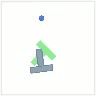
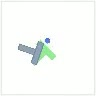
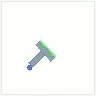
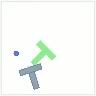
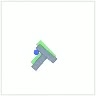
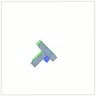

In [2]:
frames = build_demo_frames(
    TABLE_PREFIX,
    max_episodes=2,
    batch_size=BATCH_SIZE,
)
display(HTML(render_contact_sheet_html(frames)))

## Manual Frame Specs

Use explicit `(episode_index, frame_index, label)` specs when you want to narrate a particular transition.

label,episode 0 start
locator,episodes[0].observation_image_video_blob[0]
frame key,"index=0, episode=0, frame=0"
timestamp,"local=0.000s, source=0.000s"
state,"[222.00, 97.00]"
action,"[233.00, 71.00]"
reward,0.1903
done,False
task,Push the T-shaped block onto the T-shaped target.
label,episode 0 midpoint
locator,episodes[0].observation_image_video_blob[80]

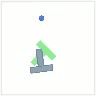
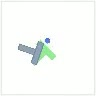
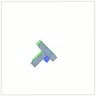

In [3]:
FRAME_SPECS = [
    (0, 0, "episode 0 start"),
    (0, 80, "episode 0 midpoint"),
    (1, 117, "episode 1 final"),
]

manual_frames = build_demo_frames(
    TABLE_PREFIX,
    frame_specs=FRAME_SPECS,
    batch_size=BATCH_SIZE,
)
display(HTML(render_contact_sheet_html(manual_frames)))